# Visual check — Roboflow images and generated masks

This notebook visually sanity-checks a few COCO-derived masks saved under `data/masks_raw/train/` against their corresponding images in `data/roboflow_coco/train/`.
It shows: original image, mask, and an overlay (mask in red).

In [1]:
%matplotlib inline
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# project_root is one level above notebooks/
project_root = Path().resolve().parent
images_dir = project_root / "data" / "roboflow_coco" / "train"
masks_dir = project_root / "data" / "masks_raw" / "train"

print(f"images_dir={images_dir}")
print(f"masks_dir={masks_dir}")

images_dir=/Users/jonatanbuga/Desktop/MRI-Project/data/roboflow_coco/train
masks_dir=/Users/jonatanbuga/Desktop/MRI-Project/data/masks_raw/train


Using 5 sample images for visual check.


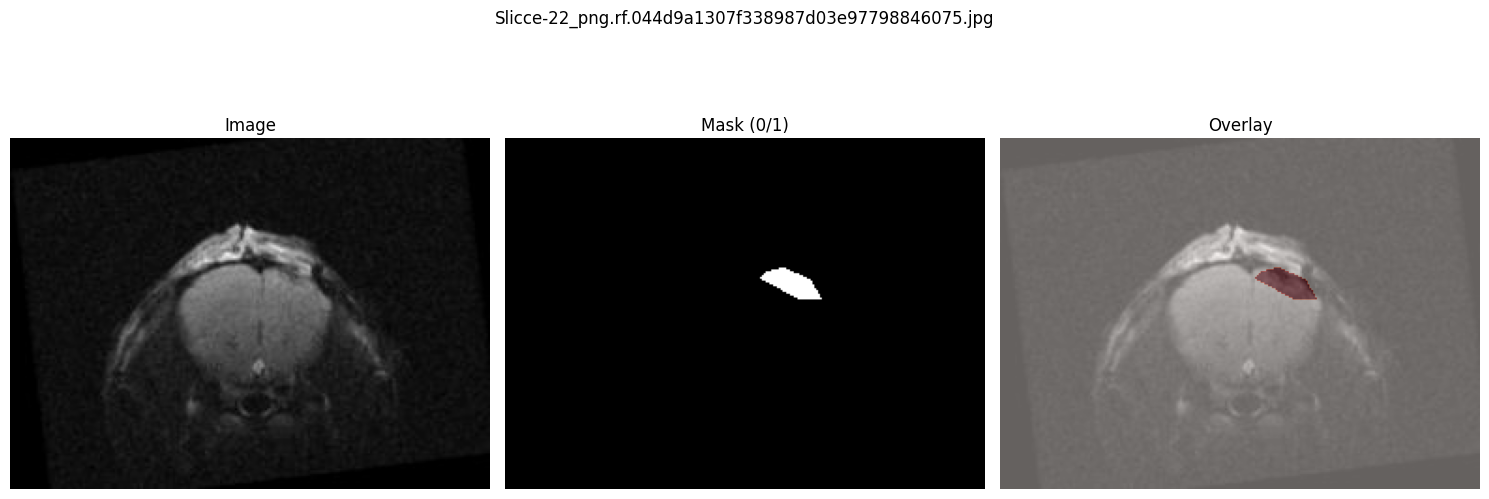

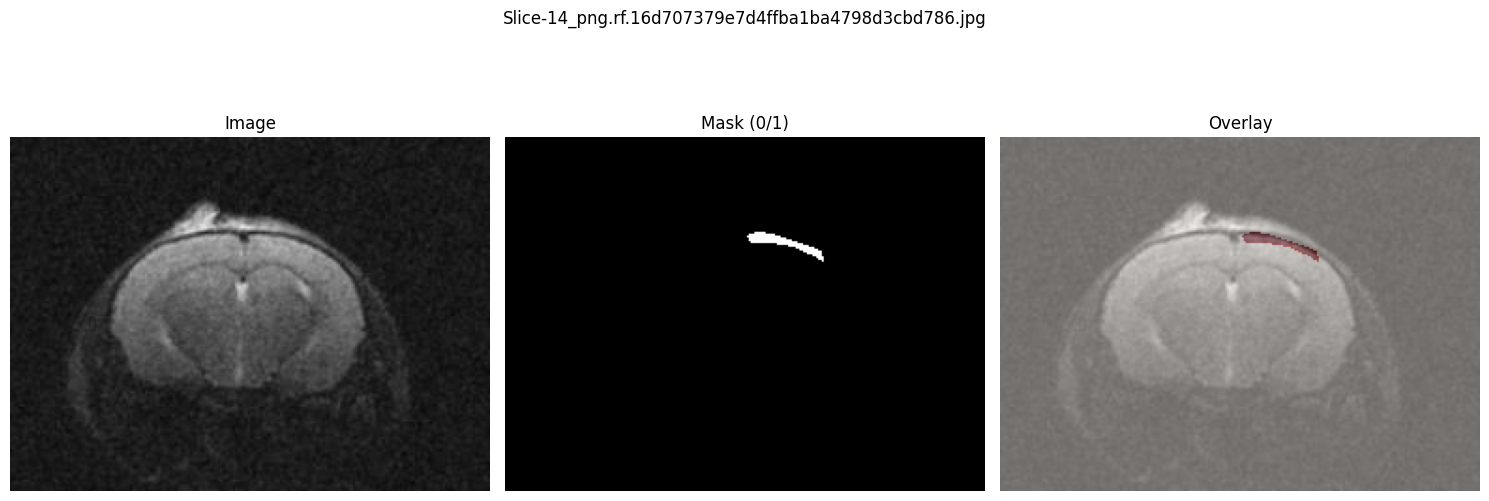

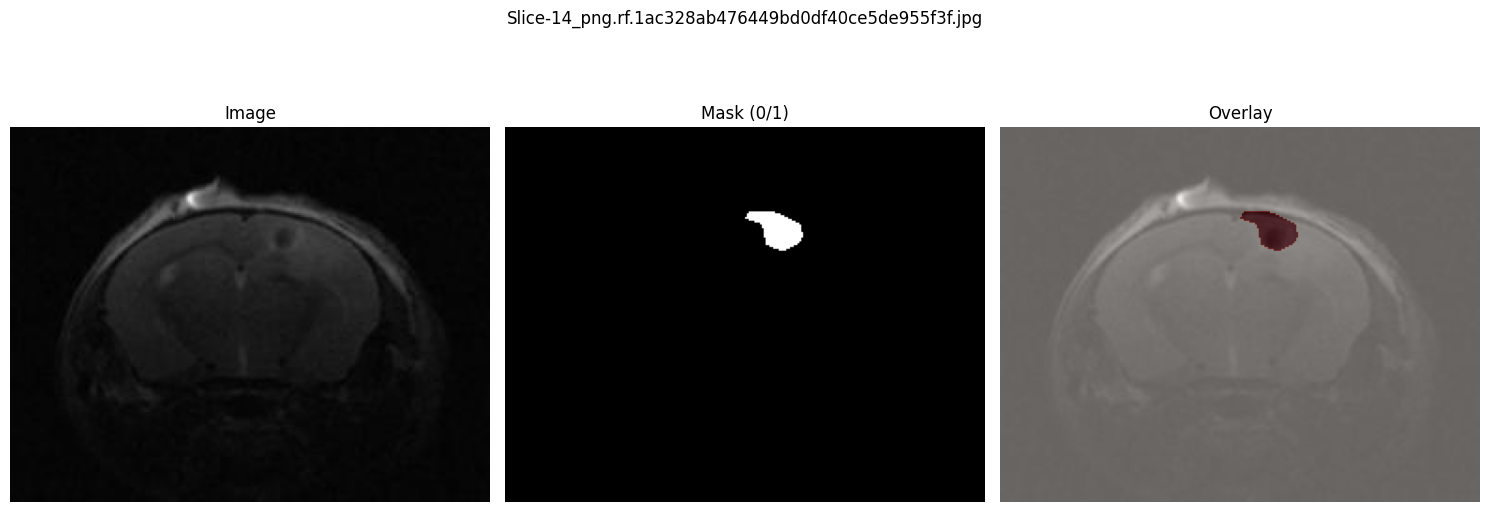

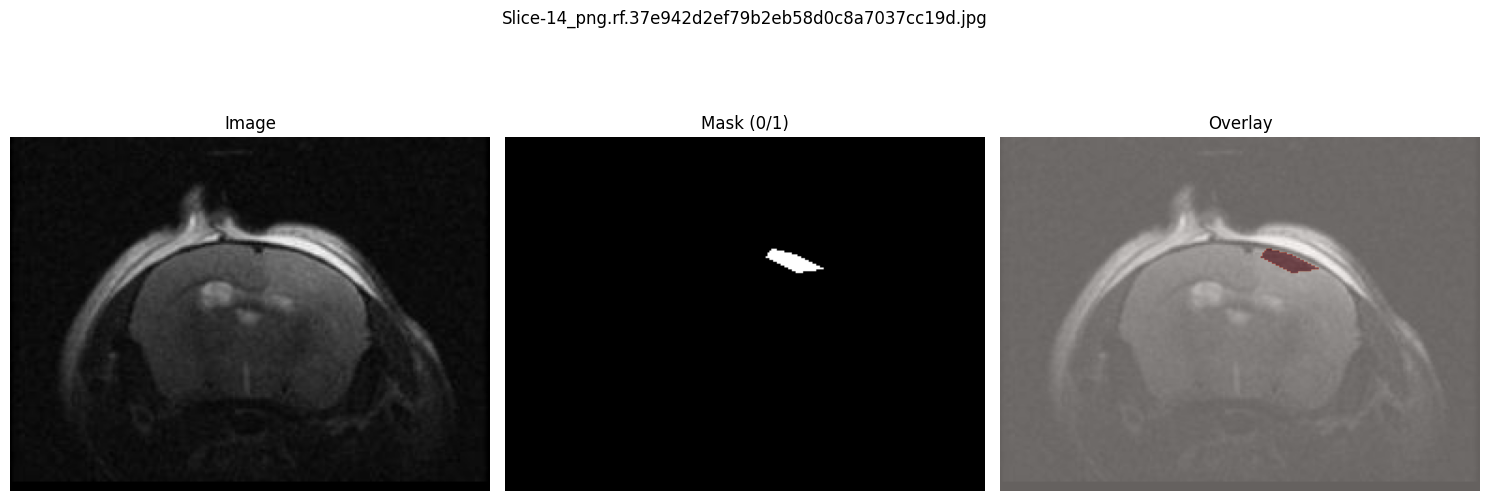

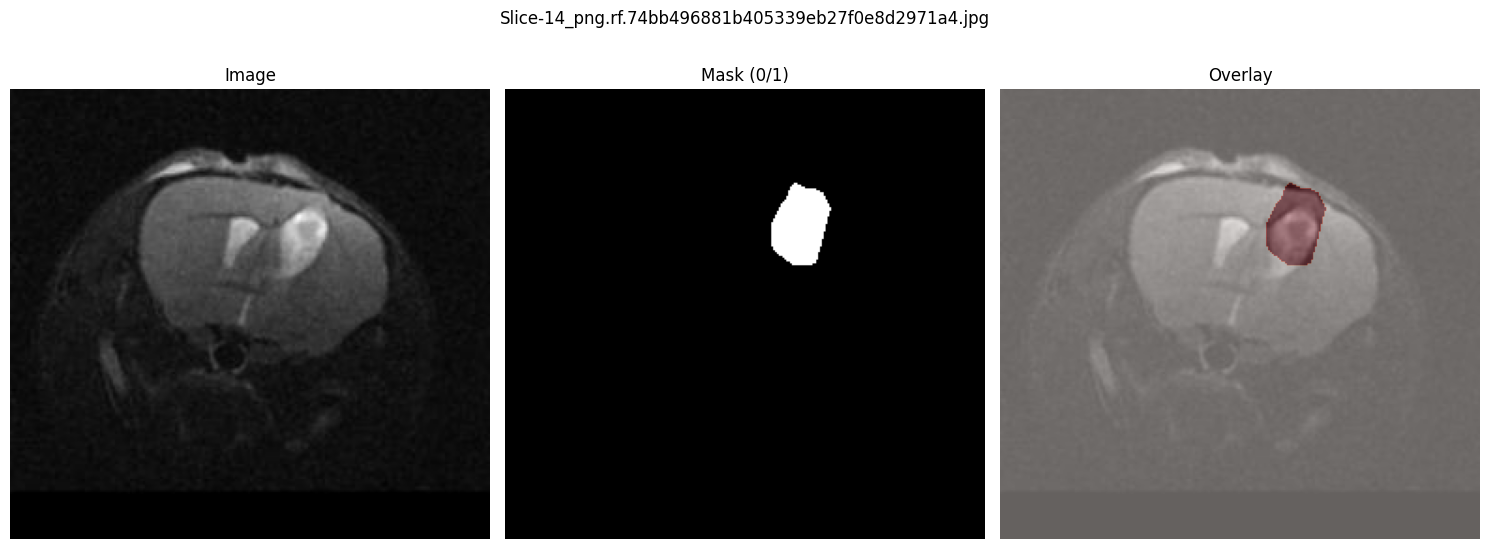

In [2]:
# collect jpg images and take first 3-5 samples
jpgs = sorted(images_dir.glob("*.jpg")) if images_dir.exists() else []
n_samples = min(5, max(3, len(jpgs))) if jpgs else 0
samples = jpgs[:n_samples]

if not samples:
    print("No .jpg images found in images_dir. Ensure coco images exist and masks were generated.")
else:
    print(f"Using {len(samples)} sample images for visual check.")

for img_path in samples:
    # load image (BGR -> RGB)
    im_bgr = cv2.imread(str(img_path))
    if im_bgr is None:
        print(f"Could not read image: {img_path}")
        continue
    im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)

    base_name = img_path.stem
    mask_path = masks_dir / f"{base_name}_mask.png"
    if not mask_path.exists():
        print(f"Mask not found for {img_path.name}: expected {mask_path}")
        # create an empty mask for visualization
        mask = np.zeros((im_rgb.shape[0], im_rgb.shape[1]), dtype=np.uint8)
    else:
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"Failed to read mask: {mask_path}")
            mask = np.zeros((im_rgb.shape[0], im_rgb.shape[1]), dtype=np.uint8)

    # Normalize mask to 0/1
    mask01 = (mask > 127).astype(np.uint8)

    # Plot: Image | Mask | Overlay
    plt.figure(figsize=(15,6))
    plt.suptitle(img_path.name, fontsize=12)

    plt.subplot(1,3,1)
    plt.imshow(im_rgb)
    plt.title('Image')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(mask01, cmap='gray')
    plt.title('Mask (0/1)')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(im_rgb)
    # show mask in red with some transparency
    plt.imshow(mask01, cmap='Reds', alpha=0.4)
    plt.title('Overlay')
    plt.axis('off')

    plt.tight_layout()
    plt.show()